Launching server at http://localhost:64276


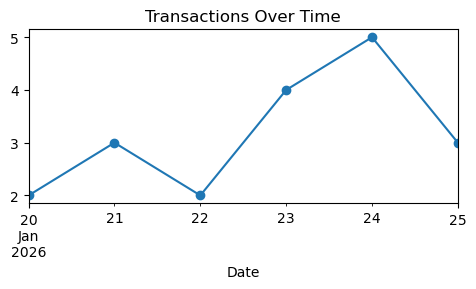

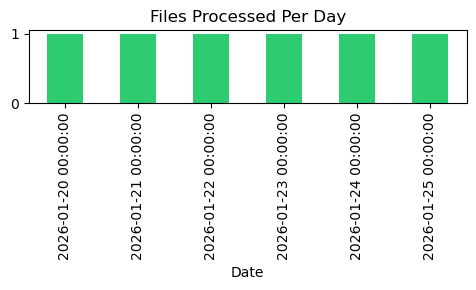

In [1]:
import os
import re
import pandas as pd
import panel as pn
import matplotlib.pyplot as plt

# Initialize Panel extension
pn.extension(design='material')

# Folder containing EDI files
folder_path = r'C:\Users\tanay\OneDrive\Downloads\EDI_PROJECT_DUMMY'


# -----------------------------------
# Function to Extract EDI Data
# -----------------------------------
def get_edi_data():

    all_po_data = []
    invalid_files = []

    # Check if folder exists
    if not os.path.exists(folder_path):
        return pd.DataFrame(), invalid_files

    # Loop through files
    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        # Process only .edi or .txt files
        if os.path.isfile(file_path) and (
            filename.endswith(".edi") or filename.endswith(".txt")
        ):

            try:

                with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
                    edi_content = file.read()

                # Extract PO Number and Date
                match = re.search(
                    r'BEG\*[^*]+\*[^*]+\*([^*]+)\*([0-9]{8})',
                    edi_content
                )

                # Extract Transaction Count
                amt_match = re.search(r'CTT\*(\d+)', edi_content)

                if match:

                    po_val = match.group(1).strip()
                    date_val = match.group(2).strip()

                    # Convert Date
                    try:
                        date_val = pd.to_datetime(
                            date_val,
                            format='%Y%m%d'
                        )

                    except:
                        date_val = None

                    # Transaction Count
                    number_val = int(amt_match.group(1)) if amt_match else 0

                    # Store Data
                    all_po_data.append({
                        "File Name": filename,
                        "PO Number": po_val,
                        "Date": date_val,
                        "Total Transactions": number_val
                    })

                else:
                    invalid_files.append(filename)

            except Exception as e:
                print(f"Error reading {filename}: {e}")

    return pd.DataFrame(all_po_data), invalid_files


# -----------------------------------
# Load Data
# -----------------------------------
df, invalid_files = get_edi_data()


# -----------------------------------
# Dashboard Components
# -----------------------------------
if df.empty:

    content = pn.pane.Alert(
        "No EDI data found. Check your files.",
        alert_type='danger'
    )

else:

    # -----------------------------------
    # Main Metrics
    # -----------------------------------
    total_files = pn.indicators.Number(
        name="Total Files",
        value=len(df),
        format='{value}',
        font_size='20pt'
    )

    total_txns = pn.indicators.Number(
        name="Total Transactions",
        value=df["Total Transactions"].sum(),
        format='{value}',
        font_size='20pt'
    )

    unique_pos = pn.indicators.Number(
        name="Unique POs",
        value=df["PO Number"].nunique(),
        format='{value}',
        font_size='20pt'
    )

    metrics_row = pn.Row(
        total_files,
        total_txns,
        unique_pos,
        styles={
            'background': '#f0f0f0',
            'padding': '10px',
            'border-radius': '5px'
        }
    )

    # -----------------------------------
    # Processing Summary Metrics
    # -----------------------------------
    successful_files = len(df)

    failed_files = len(invalid_files)

    success_rate = round(
        (successful_files / (successful_files + failed_files)) * 100,
        2
    ) if (successful_files + failed_files) > 0 else 0

    avg_transactions = round(
        df["Total Transactions"].mean(),
        2
    )

    summary_metrics = pn.Row(

        pn.indicators.Number(
            name="Successful Files",
            value=successful_files,
            format='{value}',
            font_size='18pt'
        ),

        pn.indicators.Number(
            name="Failed Files",
            value=failed_files,
            format='{value}',
            font_size='18pt'
        ),

        pn.indicators.Number(
            name="Success Rate %",
            value=success_rate,
            format='{value}%',
            font_size='18pt'
        ),

        pn.indicators.Number(
            name="Avg Transactions/File",
            value=avg_transactions,
            format='{value}',
            font_size='18pt'
        ),

        styles={
            'background': '#f9f9f9',
            'padding': '10px',
            'border-radius': '5px'
        }
    )

    # -----------------------------------
    # Exception Monitoring
    # -----------------------------------
    duplicate_pos = df[
        df.duplicated(subset=["PO Number"], keep=False)
    ]

    zero_txn_files = df[
        df["Total Transactions"] == 0
    ]

    exception_section = pn.Column(

        "## Exception Monitoring",

        pn.pane.Alert(
            f"Files Missing BEG Segment: {len(invalid_files)}",
            alert_type='danger'
        ),

        pn.pane.Alert(
            f"Duplicate PO Records: {len(duplicate_pos)}",
            alert_type='warning'
        ),

        pn.pane.Alert(
            f"Files with Zero Transactions: {len(zero_txn_files)}",
            alert_type='primary'
        )
    )

    # -----------------------------------
    # Filters
    # -----------------------------------
    po_search = pn.widgets.TextInput(
        name='Search PO Number',
        placeholder='Enter PO Number'
    )

    min_txn = pn.widgets.IntSlider(
        name='Minimum Transactions',
        start=0,
        end=int(df["Total Transactions"].max()),
        value=0
    )

    date_range = pn.widgets.DateRangeSlider(
        name='Date Range',
        start=df["Date"].min(),
        end=df["Date"].max(),
        value=(df["Date"].min(), df["Date"].max())
    )

    # -----------------------------------
    # Dynamic Filtering
    # -----------------------------------
    @pn.depends(
        po_search.param.value,
        min_txn.param.value,
        date_range.param.value
    )

    def filtered_table(po_value, min_value, date_value):

        filtered_df = df.copy()

        # PO Search
        if po_value:

            filtered_df = filtered_df[
                filtered_df["PO Number"]
                .astype(str)
                .str.contains(po_value, case=False)
            ]

        # Minimum Transaction Filter
        filtered_df = filtered_df[
            filtered_df["Total Transactions"] >= min_value
        ]

        # Date Range Filter
        start_date, end_date = date_value

        filtered_df = filtered_df[
            (filtered_df["Date"] >= start_date) &
            (filtered_df["Date"] <= end_date)
        ]

        return pn.widgets.Tabulator(
            filtered_df,
            pagination='remote',
            page_size=10,
            sizing_mode='stretch_width'
        )

    filtered_data_view = filtered_table

    # -----------------------------------
    # Charts
    # -----------------------------------

    # Transactions Over Time
    txn_by_date = df.groupby("Date")["Total Transactions"].sum()

    fig1, ax1 = plt.subplots(figsize=(5, 3))

    txn_by_date.plot(
        kind='line',
        ax=ax1,
        title="Transactions Over Time",
        marker='o'
    )

    plt.tight_layout()

    line_chart = pn.pane.Matplotlib(fig1, tight=True)

    # Files Processed Per Day
    files_per_day = df["Date"].value_counts().sort_index()

    fig2, ax2 = plt.subplots(figsize=(5, 3))

    files_per_day.plot(
        kind='bar',
        ax=ax2,
        title="Files Processed Per Day",
        color='#2ecc71'
    )

    plt.tight_layout()

    bar_chart = pn.pane.Matplotlib(fig2, tight=True)

    # -----------------------------------
    # Top Transaction Files
    # -----------------------------------
    top_files_df = df.sort_values(
        by="Total Transactions",
        ascending=False
    ).head(10)

    top_files_table = pn.widgets.Tabulator(
        top_files_df,
        pagination='local',
        page_size=10,
        sizing_mode='stretch_width'
    )

    # -----------------------------------
    # Invalid Files Table
    # -----------------------------------
    invalid_files_df = pd.DataFrame({
        "Invalid File Name": invalid_files
    })

    invalid_files_table = pn.widgets.Tabulator(
        invalid_files_df,
        pagination='local',
        page_size=5,
        sizing_mode='stretch_width'
    )

    # -----------------------------------
    # Duplicate PO Table
    # -----------------------------------
    duplicate_po_table = pn.widgets.Tabulator(
        duplicate_pos,
        pagination='local',
        page_size=5,
        sizing_mode='stretch_width'
    )

    # -----------------------------------
    # CSV Export
    # -----------------------------------
    csv_stream = pd.io.common.BytesIO()

    df.to_csv(csv_stream, index=False)

    csv_stream.seek(0)

    download_btn = pn.widgets.FileDownload(
        file=csv_stream,
        filename="edi_extracted_data.csv",
        label="Download CSV File",
        button_type='primary'
    )

    # -----------------------------------
    # Refresh Button
    # -----------------------------------
    refresh_btn = pn.widgets.Button(
        name="Refresh Dashboard",
        button_type="success"
    )

    def refresh_dashboard(event):

        global df, invalid_files

        df, invalid_files = get_edi_data()

    refresh_btn.on_click(refresh_dashboard)

    # -----------------------------------
    # Final Dashboard Layout
    # -----------------------------------
    content = pn.Column(

        "# EDI Transaction Monitoring & Analytics Dashboard",

        "### Key Metrics",
        metrics_row,

        "### Processing Summary",
        summary_metrics,

        exception_section,

        "### Filters",
        pn.Row(po_search, min_txn),

        date_range,

        "### Extracted EDI Data",
        filtered_data_view,

        pn.Row(line_chart, bar_chart),

        "## Top Transaction Files",
        top_files_table,

        "## Duplicate PO Records",
        duplicate_po_table,

        "## Invalid Files",
        invalid_files_table,

        "### Export & Refresh",
        pn.Row(refresh_btn, download_btn),

        sizing_mode='stretch_width'
    )


# -----------------------------------
# Launch Dashboard
# -----------------------------------
content.show()

# OR use:
# content.servable()